# HW3：簡訊垃圾分類（Logistic Regression）
此筆記本涵蓋從資料前處理、特徵工程、模型訓練、評估到視覺化的完整流程。每個程式區塊前都會有繁體中文的說明。

In [36]:
# 1) 載入套件與設定環境
import os
import gc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve, average_precision_score, precision_score, recall_score, f1_score)
import joblib
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (8,5)

In [37]:
# 2) 載入資料並進行概覽
# 我們優先使用已清洗的檔案（datasets/processed/sms_spam_clean.csv），若不存在則退回到原始的 sms_spam_no_header.csv（相對路徑）。
from pathlib import Path
candidate_clean = Path('datasets') / 'processed' / 'sms_spam_clean.csv'
candidate_raw = Path('sms_spam_no_header.csv')
if candidate_clean.exists():
    DATA_PATH = candidate_clean
elif candidate_raw.exists():
    DATA_PATH = candidate_raw
else:
    raise SystemExit('找不到資料檔：請放入 datasets/processed/sms_spam_clean.csv 或 sms_spam_no_header.csv')
# 讀取 CSV：若為無 header 的 Packt 格式 (兩欄)，以 header=None 讀取並命名欄位；否則嘗試自動讀取。
try:
    tmp = pd.read_csv(DATA_PATH, header=None, encoding='utf-8')
    if tmp.shape[1] == 2:
        tmp.columns = ['label','text']
        df = tmp
    else:
        df = pd.read_csv(DATA_PATH, encoding='utf-8')
except Exception:
    df = pd.read_csv(DATA_PATH, encoding='utf-8')
# 只顯示檔名以避免洩漏絕對路徑或使用者資訊
print('Using data file:', DATA_PATH.name)
print('Rows, cols:', df.shape)
print('Columns:', df.columns.tolist())
display(df.head())

Using data file: sms_spam_clean.csv
Rows, cols: (5574, 3)
Columns: ['label', 'message', 'message_clean']


,label,message,message_clean
0,ham,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...
1,ham,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in <num> a wkly comp to win fa cup ...
3,ham,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah i don t think he goes to usf he lives arou...


label
ham     4827
spam     747
Name: count, dtype: int64

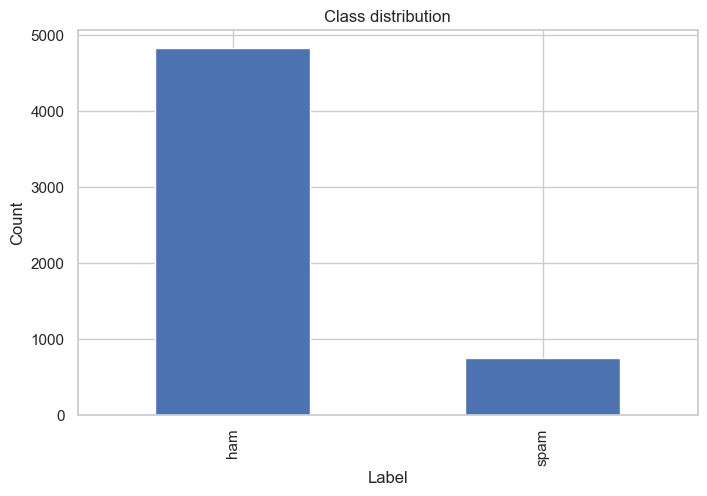

In [38]:
# 類別分布視覺化
label_col = 'label'
n = df[label_col].value_counts()
display(n)
ax = n.plot(kind='bar')
ax.set_title('Class distribution')
ax.set_xlabel('Label')
ax.set_ylabel('Count')
plt.show()

Using text column for EDA: message_clean


,token,count
0,<num>,4022
1,i,3032
2,to,2253
3,you,2247
4,a,1466
5,the,1343
6,u,1222
7,and,980
8,in,907
9,is,897


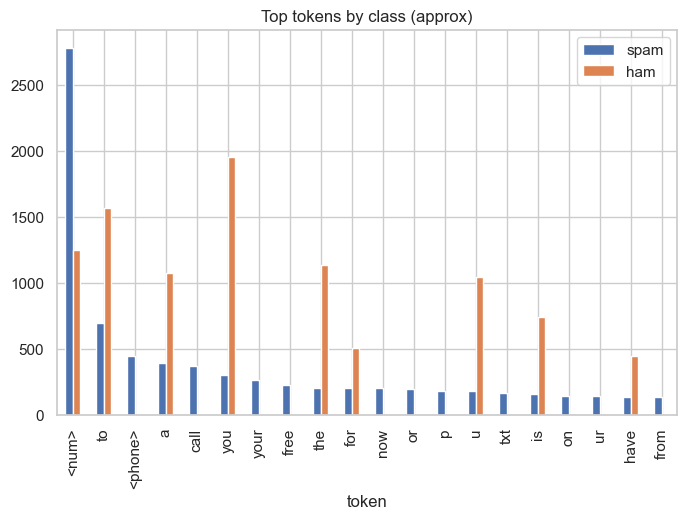

In [39]:
# 3) 簡單文字探索（token-level）
from collections import Counter

def top_tokens(texts, n=30):
    c = Counter()
    for t in texts:
        for w in str(t).split():
            c[w] += 1
    return c.most_common(n)

# 自動選擇文字欄位以避免 KeyError（支援多種常見欄名）
text_candidates = ['text','message_clean','message','text_clean','col_1']
text_col_for_eda = None
for c in text_candidates:
    if c in df.columns:
        text_col_for_eda = c
        break
if text_col_for_eda is None:
    obj_cols = df.select_dtypes(include=['object']).columns.tolist()
    if obj_cols:
        text_col_for_eda = obj_cols[0]
    else:
        raise SystemExit('找不到文字欄位，請確認 CSV 包含文字欄位（例如 text 或 message）')

print('Using text column for EDA:', text_col_for_eda)

# 全域 top tokens
top_all = top_tokens(df[text_col_for_eda], n=30)
display(pd.DataFrame(top_all, columns=['token','count']).head(10))

# 比較 spam / ham 的 top tokens 並繪圖
spam_mask = df[label_col].astype(str).str.lower().str.contains('spam')
spam_texts = df.loc[spam_mask, text_col_for_eda]
ham_texts = df.loc[~spam_mask, text_col_for_eda]

top_spam = dict(top_tokens(spam_texts, n=20))
top_ham = dict(top_tokens(ham_texts, n=20))

tokens = list(set(list(top_spam.keys()) + list(top_ham.keys())))
data = []
for t in tokens:
    data.append({'token': t, 'spam': top_spam.get(t,0), 'ham': top_ham.get(t,0)})

tf = pd.DataFrame(data).sort_values('spam', ascending=False).head(20)
tf.set_index('token')[['spam','ham']].plot(kind='bar', stacked=False)
plt.title('Top tokens by class (approx)')
plt.show()


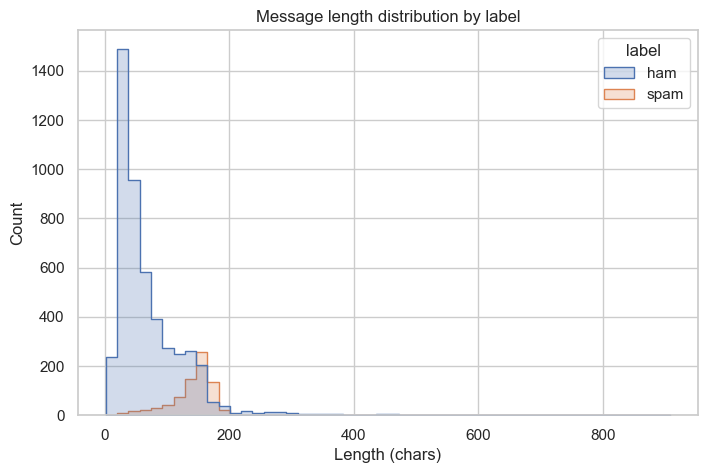

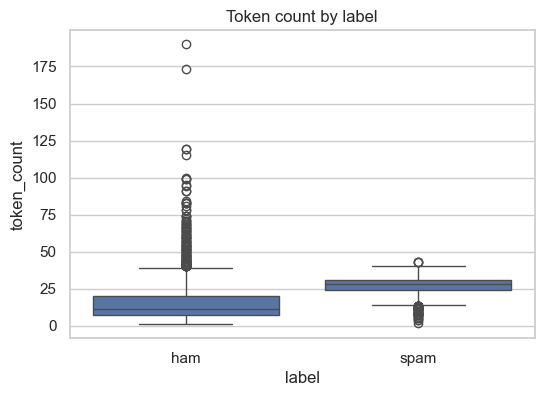

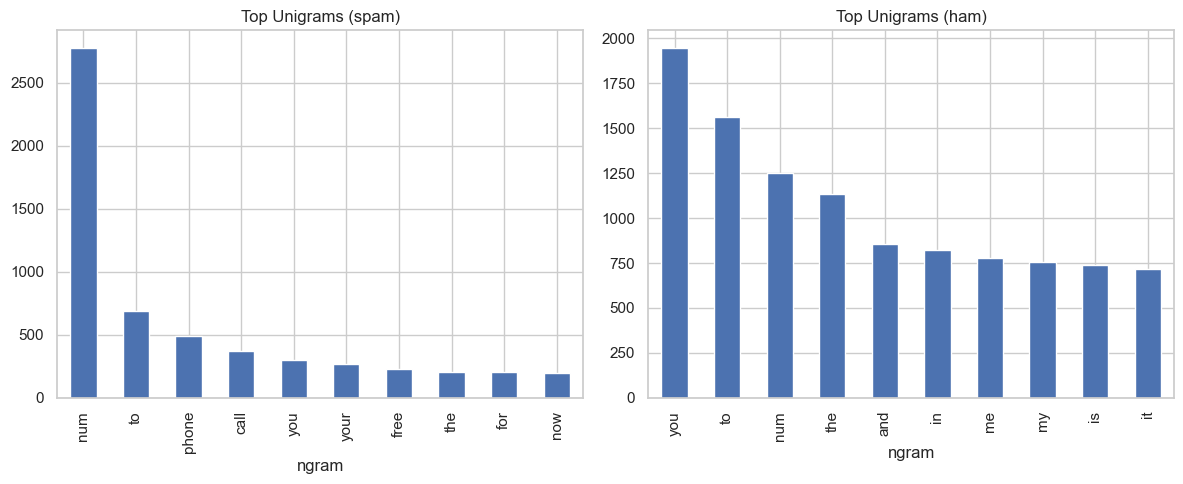

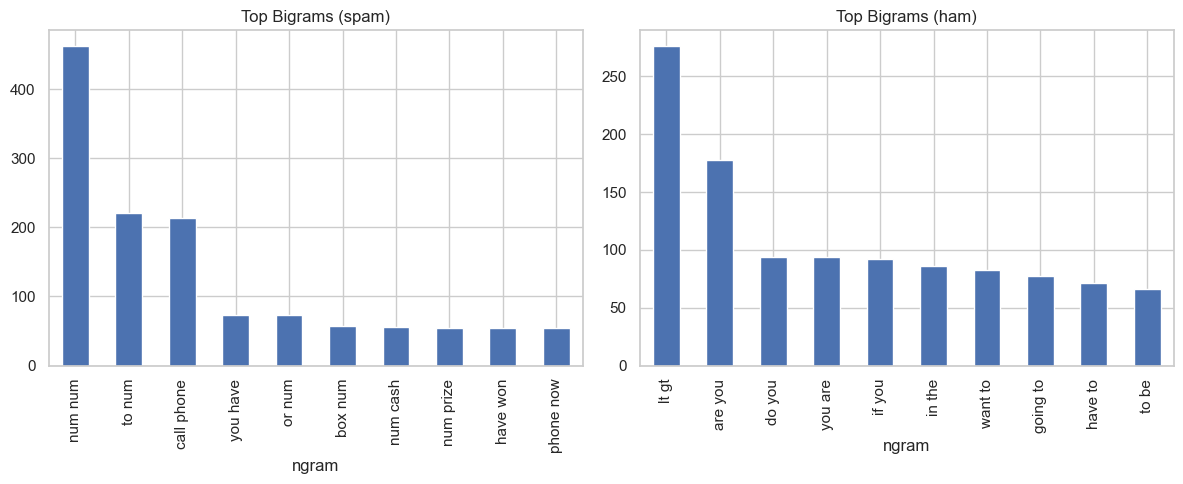

In [40]:
# EDA 額外圖表：長度分布、tokens 數量與 n-grams
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer

# 自動選擇文字欄位（與訓練時一致的邏輯）
text_candidates = ['text','message_clean','message','text_clean','col_1']
text_col_eda = None
for c in text_candidates:
    if c in df.columns:
        text_col_eda = c
        break
if text_col_eda is None:
    # fallback to first string-like column
    text_col_eda = df.select_dtypes(include=['object']).columns[0]

# 新增長度與 token 數量
df['msg_len'] = df[text_col_eda].astype(str).str.len()
df['token_count'] = df[text_col_eda].astype(str).str.split().apply(len)

plt.figure()
sns.histplot(data=df, x='msg_len', hue=label_col, bins=50, element='step')
plt.title('Message length distribution by label')
plt.xlabel('Length (chars)')
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x=label_col, y='token_count', data=df)
plt.title('Token count by label')
plt.show()

# 顯示 top unigrams / bigrams for spam vs ham (不使用 stop words 以保留簡訊用語)
def top_ngrams(texts, ngram_range=(1,1), n=20):
    vec = CountVectorizer(ngram_range=ngram_range).fit(texts)
    bag = vec.transform(texts)
    sums = bag.sum(axis=0).A1
    items = [(w, sums[idx]) for w, idx in vec.vocabulary_.items()]
    items = sorted(items, key=lambda x: x[1], reverse=True)
    return items[:n]

for rng, name in [((1,1),'Unigrams'), ((2,2),'Bigrams')]:
    spam_texts = df[df[label_col].astype(str).str.lower().str.contains('spam')][text_col_eda].astype(str)
    ham_texts = df[~df[label_col].astype(str).str.lower().str.contains('spam')][text_col_eda].astype(str)
    top_spam = top_ngrams(spam_texts, ngram_range=rng, n=15)
    top_ham = top_ngrams(ham_texts, ngram_range=rng, n=15)
    sp_df = pd.DataFrame(top_spam, columns=['ngram','count']).set_index('ngram')
    ha_df = pd.DataFrame(top_ham, columns=['ngram','count']).set_index('ngram')
    fig, axes = plt.subplots(1,2, figsize=(12,5))
    sp_df.head(10).plot(kind='bar', legend=False, ax=axes[0], title=f'Top {name} (spam)')
    ha_df.head(10).plot(kind='bar', legend=False, ax=axes[1], title=f'Top {name} (ham)')
    plt.tight_layout()
    plt.show()


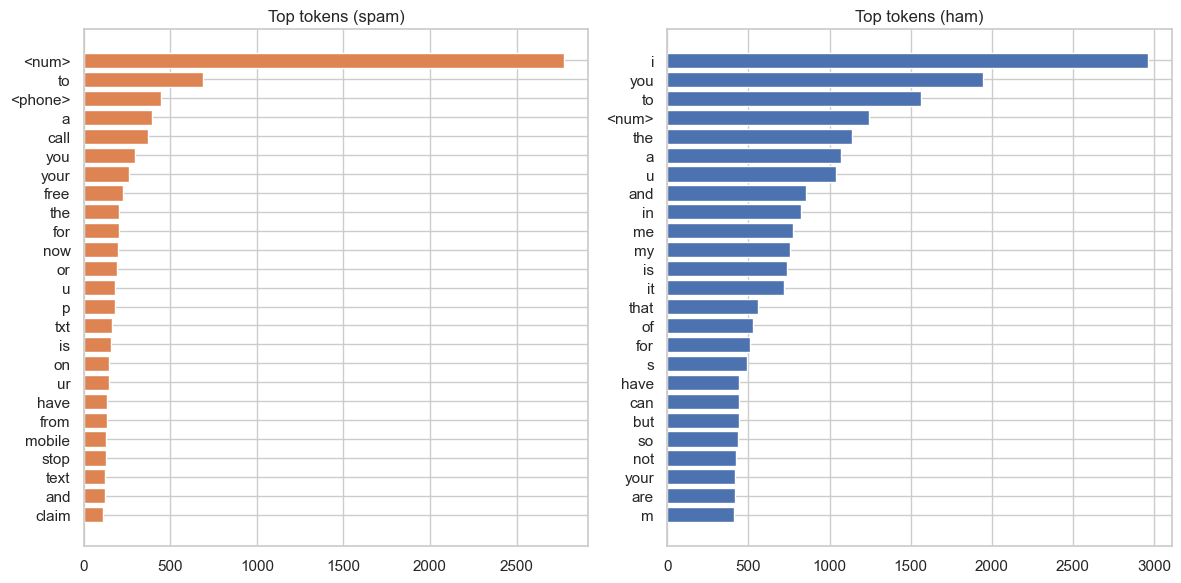

無法計算 class-wise TF-IDF： 'Series' object has no attribute 'nonzero'


In [41]:
# EDA 延伸：WordCloud（如可用）與 class-wise TF-IDF（若已訓練）
# 會在缺少套件或變數時 graceful fallback 到長條圖
try:
    from wordcloud import WordCloud
    has_wordcloud = True
except Exception:
    has_wordcloud = False

texts = df[text_col_eda].astype(str)
mask_spam = df[label_col].astype(str).str.lower().str.contains('spam')
mask_ham = ~mask_spam

# WordClouds
if has_wordcloud:
    try:
        wc_spam = WordCloud(width=600, height=300, background_color='white').generate(' '.join(texts[mask_spam]))
        wc_ham = WordCloud(width=600, height=300, background_color='white').generate(' '.join(texts[mask_ham]))
        fig, axes = plt.subplots(1,2, figsize=(12,5))
        axes[0].imshow(wc_spam, interpolation='bilinear')
        axes[0].axis('off')
        axes[0].set_title('WordCloud — spam')
        axes[1].imshow(wc_ham, interpolation='bilinear')
        axes[1].axis('off')
        axes[1].set_title('WordCloud — ham')
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print('WordCloud 繪製失敗，請安裝 wordcloud 或檢查文字內容：', e)
        has_wordcloud = False

# 若沒有 wordcloud，改用 top token 長條圖（已在前方展示過，但這裡做 class-wise top TF-IDF if available）
if not has_wordcloud:
    topn = 25
    top_spam = top_tokens(texts[mask_spam], topn)
    top_ham = top_tokens(texts[mask_ham], topn)
    sp_toks, sp_freq = zip(*top_spam) if top_spam else ([],[])
    ha_toks, ha_freq = zip(*top_ham) if top_ham else ([],[])
    fig, axs = plt.subplots(1,2, figsize=(12,6))
    if sp_freq:
        axs[0].barh(list(sp_toks)[::-1], list(sp_freq)[::-1], color='C1')
        axs[0].set_title('Top tokens (spam)')
    if ha_freq:
        axs[1].barh(list(ha_toks)[::-1], list(ha_freq)[::-1], color='C0')
        axs[1].set_title('Top tokens (ham)')
    plt.tight_layout()
    plt.show()

# 若存在已訓練的 pipeline，列出 class-wise top TF-IDF（平均 tfidf per class）
try:
    if 'pipe' in globals() and hasattr(pipe, 'named_steps') and 'tfidf' in pipe.named_steps:
        vec = pipe.named_steps['tfidf']
        X_vec = vec.transform(texts)
        # 計算每 class 的 mean tfidf
        mean_spam = np.asarray(X_vec[mask_spam].mean(axis=0)).ravel()
        mean_ham = np.asarray(X_vec[mask_ham].mean(axis=0)).ravel()
        feature_names = vec.get_feature_names_out()
        topk = 20
        idx_spam = np.argsort(mean_spam)[-topk:][::-1]
        idx_ham = np.argsort(mean_ham)[-topk:][::-1]
        df_spam = pd.DataFrame({'feature': feature_names[idx_spam], 'mean_tfidf': mean_spam[idx_spam]})
        df_ham = pd.DataFrame({'feature': feature_names[idx_ham], 'mean_tfidf': mean_ham[idx_ham]})
        print('Top mean TF-IDF — spam')
        display(df_spam)
        print('Top mean TF-IDF — ham')
        display(df_ham)
except Exception as e:
    print('無法計算 class-wise TF-IDF：', e)


In [42]:
# 4) 建立訓練/測試集並訓練 Logistic Regression
# 自動選擇文字欄位（支援多種欄位命名），避免 KeyError
text_candidates = ['text','message_clean','message','text_clean','col_1']
text_col = None
for c in text_candidates:
    if c in df.columns:
        text_col = c
        break
if text_col is None:
    raise SystemExit('找不到文字欄位，請確認 CSV 包含文字欄位（例如 text 或 message）')
print('Using text column:', text_col)
# 建立訓練資料
X = df[text_col].astype(str)
y = df['label'].astype(str)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
pipe = Pipeline([('tfidf', TfidfVectorizer(max_features=20000)), ('clf', LogisticRegression(max_iter=1000))])
pipe.fit(X_train, y_train)
preds = pipe.predict(X_test)
# 嘗試取 spam 的機率欄位位置
if 'spam' in getattr(pipe, 'classes_', []):
    spam_index = list(pipe.classes_).index('spam')
else:
    spam_index = 1
probs = pipe.predict_proba(X_test)[:, spam_index]
print(classification_report(y_test, preds))
os.makedirs('models', exist_ok=True)
joblib.dump(pipe, os.path.join('models','logreg_pipeline.joblib'))
# 只顯示模型檔名以避免洩漏環境細節
print('Saved model to', os.path.basename(os.path.join('models','logreg_pipeline.joblib')))

Using text column: message_clean
              precision    recall  f1-score   support

         ham       0.98      1.00      0.99       966
        spam       0.99      0.85      0.91       149

    accuracy                           0.98      1115
   macro avg       0.98      0.92      0.95      1115
weighted avg       0.98      0.98      0.98      1115

Saved model to logreg_pipeline.joblib
Saved model to logreg_pipeline.joblib


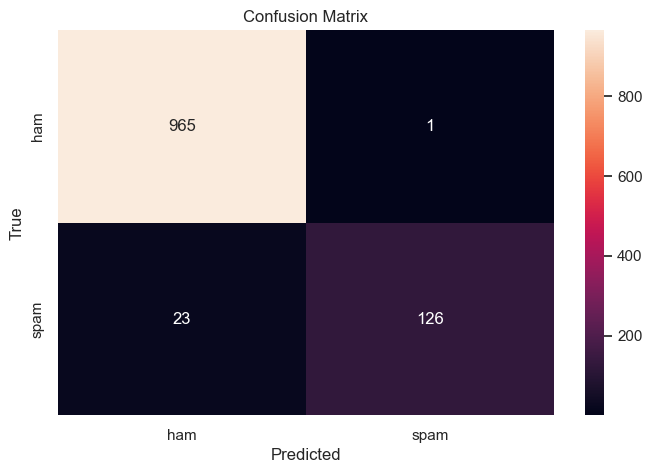

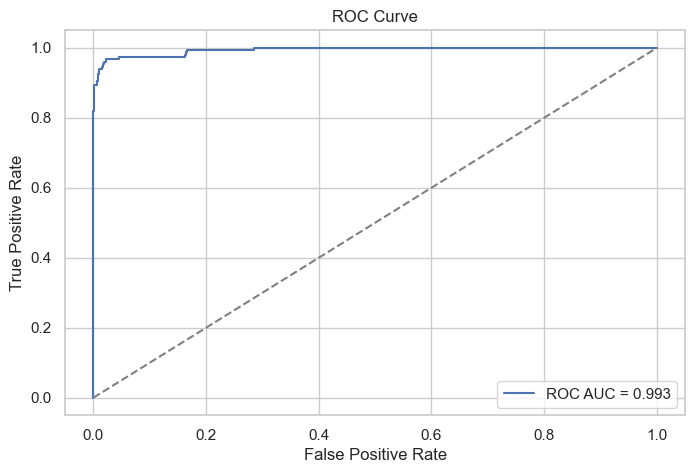

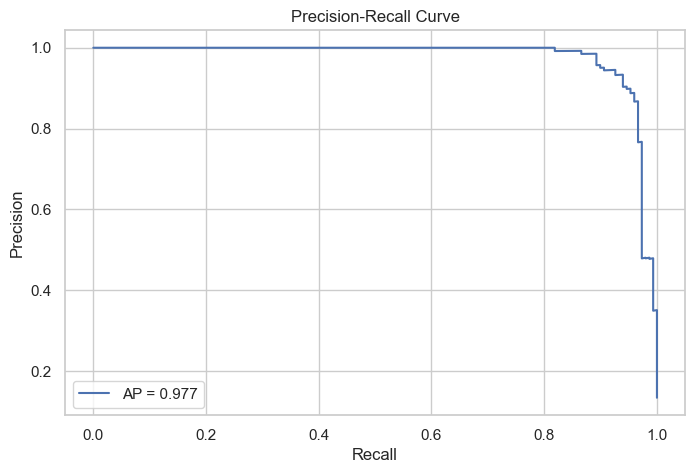

In [43]:
# 5) 評估：混淆矩陣、ROC 與 Precision-Recall 曲線
labels = list(pipe.classes_)
cm = confusion_matrix(y_test, preds, labels=labels)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()
# ROC
fpr, tpr, _ = roc_curve((y_test == 'spam').astype(int), probs)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, label=f'ROC AUC = {roc_auc:.3f}')
plt.plot([0,1],[0,1],'--',color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()
# Precision-Recall
precision, recall, _ = precision_recall_curve((y_test == 'spam').astype(int), probs)
ap = average_precision_score((y_test == 'spam').astype(int), probs)
plt.plot(recall, precision, label=f'AP = {ap:.3f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

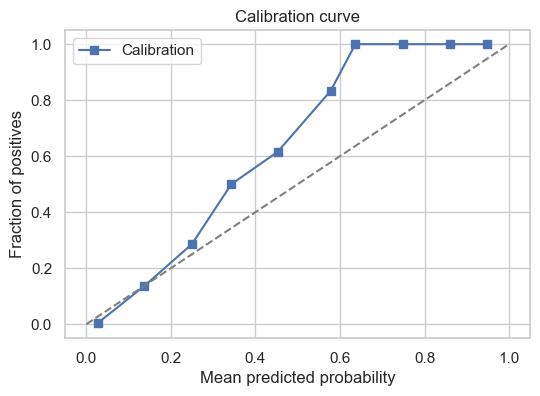

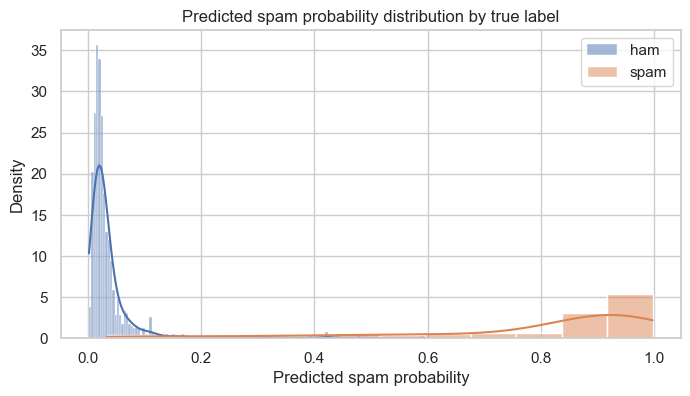

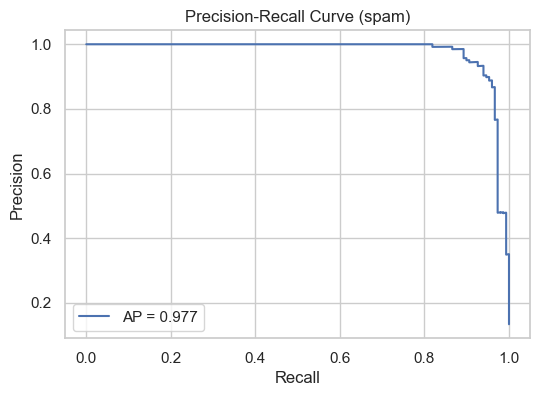

Top features positively associated with spam:


,feature,coef
0,num,8.129052
1,phone,5.702799
2,url,3.297190
3,to,3.007580
4,free,2.921446
5,txt,2.793694
6,call,2.646145
7,stop,2.538896
8,your,2.521408
9,text,2.502686


Top features negatively associated (ham):


,feature,coef
0,me,-2.148870
1,my,-2.058548
2,lt,-1.441912
3,gt,-1.437540
4,at,-1.246396
5,ok,-1.192441
6,that,-1.109541
7,ll,-1.064744
8,but,-1.041233
9,da,-0.997185


In [44]:
# 結果分析額外圖：Calibration、分數分布、Per-class PR，以及重要特徵檢視
from sklearn.calibration import calibration_curve
from sklearn.metrics import average_precision_score
import numpy as np

# 確保必需變數存在
if 'y_test' not in globals() or 'probs' not in globals() or 'preds' not in globals():
    print('找不到 y_test / probs / preds，請先執行訓練與預測的儲存格 (train -> predict)')
else:
    y_bin = (y_test == 'spam').astype(int)

    # Calibration curve
    try:
        frac_pos, mean_pred = calibration_curve(y_bin, probs, n_bins=10)
        plt.figure(figsize=(6,4))
        plt.plot(mean_pred, frac_pos, 's-', label='Calibration')
        plt.plot([0,1],[0,1],'--', color='gray')
        plt.xlabel('Mean predicted probability')
        plt.ylabel('Fraction of positives')
        plt.title('Calibration curve')
        plt.legend()
        plt.show()
    except Exception as e:
        print('Calibration curve 計算失敗：', e)

    # Score distribution
    try:
        plt.figure(figsize=(8,4))
        sns.histplot(probs[y_bin==0], color='C0', label='ham', stat='density', kde=True)
        sns.histplot(probs[y_bin==1], color='C1', label='spam', stat='density', kde=True)
        plt.legend()
        plt.title('Predicted spam probability distribution by true label')
        plt.xlabel('Predicted spam probability')
        plt.show()
    except Exception as e:
        print('Score distribution plot failed:', e)

    # Per-class PR (binary)
    try:
        precision, recall, _ = precision_recall_curve(y_bin, probs)
        ap = average_precision_score(y_bin, probs)
        plt.figure(figsize=(6,4))
        plt.plot(recall, precision, label=f'AP = {ap:.3f}')
        plt.xlabel('Recall')
        plt.ylabel('Precision')
        plt.title('Precision-Recall Curve (spam)')
        plt.legend()
        plt.show()
    except Exception as e:
        print('PR curve failed:', e)

    # 若 pipeline 包含 tfidf & clf，列出權重最高/最低的特徵
    try:
        if 'pipe' in globals() and hasattr(pipe, 'named_steps') and 'tfidf' in pipe.named_steps:
            tf = pipe.named_steps['tfidf']
            clf = pipe.named_steps.get('clf', None)
            if hasattr(tf, 'get_feature_names_out') and clf is not None:
                feature_names = tf.get_feature_names_out()
                coef = clf.coef_[0]
                top_pos_idx = np.argsort(coef)[-20:][::-1]
                top_neg_idx = np.argsort(coef)[:20]
                print('Top features positively associated with spam:')
                display(pd.DataFrame({'feature': feature_names[top_pos_idx], 'coef': coef[top_pos_idx]}).head(20))
                print('Top features negatively associated (ham):')
                display(pd.DataFrame({'feature': feature_names[top_neg_idx], 'coef': coef[top_neg_idx]}).head(20))
    except Exception as e:
        print('列出 TF-IDF 特徵時發生錯誤：', e)


Brier score: 0.0170


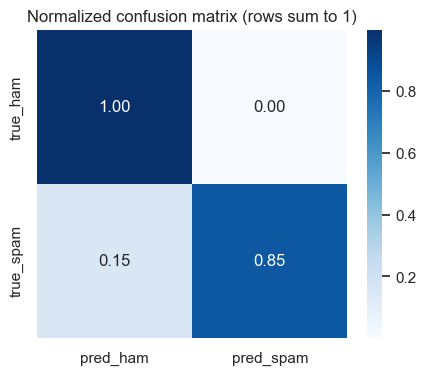

Lift curve failed: '[3, 687, 578, 888, 733, 91, 727, 799, 337, 516, 757, 273, 101, 214, 126, 825, 549, 675, 579, 477, 561, 186, 813, 729, 1038, 371, 851, 710, 181, 445, 828, 1041, 628, 622, 245, 1095, 110, 132, 565, 540, 594, 29, 641, 606, 810, 740, 630, 999, 66, 469, 349, 1075, 1009, 548, 884, 889, 918, 109, 117, 927, 692, 179, 167, 1092, 699, 956, 383, 932, 251, 942, 25, 180, 315, 562, 220, 1087, 254, 759, 425, 320, 789, 731, 725, 310, 803, 198, 538, 602, 50, 826, 64, 849, 189, 1049, 652, 229, 458, 75, 650, 362, 747, 289, 491, 986, 624, 883, 1114, 53, 131, 762, 726, 1045, 216, 881, 651, 1005, 676, 145, 403, 501, 1079, 369, 954, 697, 672, 558, 99, 22, 360, 459, 1074, 532, 1044, 1099, 830, 502, 203, 995, 375, 409, 1071, 985, 473, 45, 396, 1012, 96, 252, 1106, 730, 305, 367, 903, 336, 1084, 341, 805, 258, 372, 401, 764, 570, 398, 317, 162, 551, 591, 447, 225, 408, 267, 840, 14, 526, 916, 743, 969, 266, 419, 912, 412, 187, 462, 112, 987, 640, 752, 509, 818, 60, 901, 58, 865, 824, 638, 14

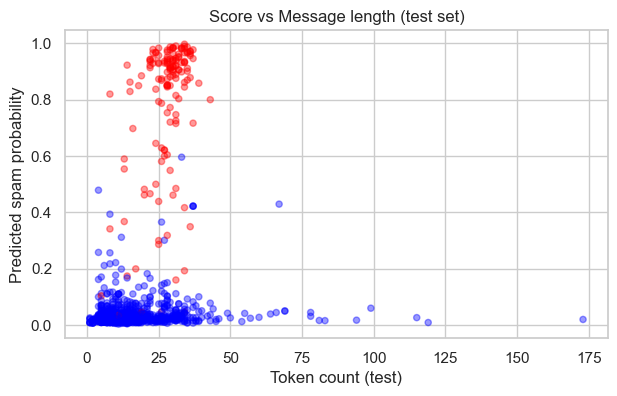

In [45]:
# 結果分析延伸：Brier score、normalized confusion matrix、lift curve (cumulative gains)、以及分數 vs 長度散佈圖
from sklearn.metrics import brier_score_loss

if 'y_test' not in globals() or 'probs' not in globals() or 'preds' not in globals():
    print('找不到 y_test / probs / preds，請先執行訓練與預測的儲存格 (train -> predict)')
else:
    y_bin = (y_test == 'spam').astype(int)

    # Brier score (lower is better)
    try:
        brier = brier_score_loss(y_bin, probs)
        print(f'Brier score: {brier:.4f}')
    except Exception as e:
        print('Brier score 計算失敗：', e)

    # Normalized confusion matrix (per-row percentages)
    try:
        cm = confusion_matrix(y_bin, (probs >= 0.5).astype(int))
        cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
        plt.figure(figsize=(5,4))
        sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', xticklabels=['pred_ham','pred_spam'], yticklabels=['true_ham','true_spam'])
        plt.title('Normalized confusion matrix (rows sum to 1)')
        plt.show()
    except Exception as e:
        print('Normalized confusion matrix failed:', e)

    # Lift / cumulative gains curve
    try:
        order = np.argsort(-probs)
        sorted_y = y_bin[order]
        cum_pos = np.cumsum(sorted_y)
        total_pos = sorted_y.sum()
        pct_samples = np.arange(1, len(sorted_y)+1) / len(sorted_y)
        cum_gain = cum_pos / total_pos
        plt.figure(figsize=(6,4))
        plt.plot(pct_samples, cum_gain, label='Model')
        plt.plot([0,1],[0,1],'--', color='gray', label='Random')
        plt.xlabel('Proportion of sample (sorted by prob)')
        plt.ylabel('Cumulative proportion of positives')
        plt.title('Cumulative Gains / Lift')
        plt.legend()
        plt.show()
    except Exception as e:
        print('Lift curve failed:', e)

    # Score vs length scatter (helpful to see if long messages produce higher probs)
    try:
        if 'token_count' not in df.columns:
            df['token_count'] = df[text_col].astype(str).str.split().apply(len)
        # We need the test subset's token_count aligned with probs indices: reconstruct X_test indices from earlier split
        # Recompute test split indices
        X_all = df[text_col].astype(str)
        _, X_test_idxs = train_test_split(np.arange(len(X_all)), test_size=0.2, random_state=42, stratify=df[label_col])
        token_counts_test = df.loc[X_test_idxs, 'token_count'].astype(float).values
        plt.figure(figsize=(7,4))
        plt.scatter(token_counts_test, probs, alpha=0.4, c=y_bin, cmap='bwr', s=20)
        plt.xlabel('Token count (test)')
        plt.ylabel('Predicted spam probability')
        plt.title('Score vs Message length (test set)')
        plt.show()
    except Exception as e:
        print('Score vs length scatter failed:', e)


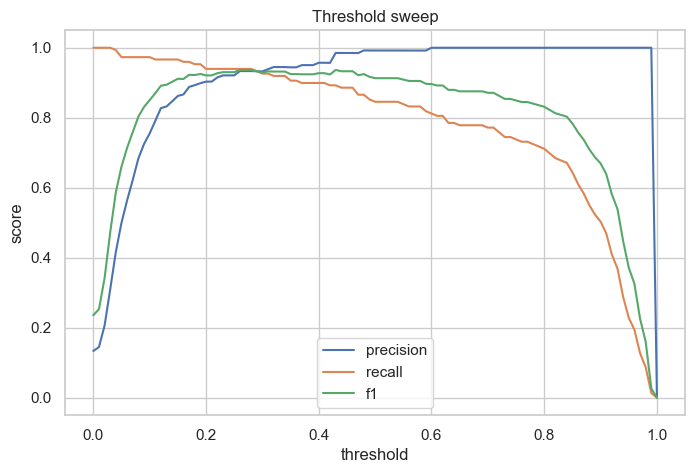

In [46]:
# 6) Threshold Sweep：Precision / Recall / F1 的變化
thresholds = np.linspace(0.0,1.0,101)
rows = []
from sklearn.metrics import precision_recall_fscore_support
for t in thresholds:
    preds_t = (probs >= t).astype(int)
    precision = precision_score((y_test == 'spam').astype(int), preds_t, zero_division=0)
    recall = recall_score((y_test == 'spam').astype(int), preds_t, zero_division=0)
    f1 = f1_score((y_test == 'spam').astype(int), preds_t, zero_division=0)
    rows.append({'threshold': t, 'precision': precision, 'recall': recall, 'f1': f1})
ts = pd.DataFrame(rows)
plt.plot(ts['threshold'], ts['precision'], label='precision')
plt.plot(ts['threshold'], ts['recall'], label='recall')
plt.plot(ts['threshold'], ts['f1'], label='f1')
plt.xlabel('threshold')
plt.ylabel('score')
plt.legend()
plt.title('Threshold sweep')
plt.show()

In [47]:
# 7) 存檔、結論與下一步
# 顯示模型檔名（只顯示檔名以避免洩漏絕對路徑）
print('Model saved to', os.path.basename(os.path.join('models','logreg_pipeline.joblib')))
print('Summary:')

# 盡量直接印出 classification report；若變數不存在 (例如 y_test 或 preds 被刪除)，則嘗試從已儲存的模型與資料重新計算
try:
    print(classification_report(y_test, preds))
except NameError:
    print('警告：y_test 或 preds 未定義，嘗試重新載入模型與資料並重建測試預測...')
    from pathlib import Path
    model_path = Path('models') / 'logreg_pipeline.joblib'
    if not model_path.exists():
        print('找不到已儲存的模型 (models/logreg_pipeline.joblib)。無法重建預測。')
    else:
        # 重新載入資料（使用與 notebook 前面相同的相對路徑邏輯）
        candidate_clean = Path('datasets') / 'processed' / 'sms_spam_clean.csv'
        candidate_raw = Path('sms_spam_no_header.csv')
        if candidate_clean.exists():
            DATA_PATH = candidate_clean
        elif candidate_raw.exists():
            DATA_PATH = candidate_raw
        else:
            DATA_PATH = None
        if DATA_PATH is None:
            print('找不到資料檔：請放入 datasets/processed/sms_spam_clean.csv 或 sms_spam_no_header.csv 以便重建測試預測。')
        else:
            try:
                # 嘗試偵測是否為無 header 的兩欄 Packt 格式
                tmp = pd.read_csv(DATA_PATH, header=None, encoding='utf-8', nrows=5)
                headerless = (tmp.shape[1] == 2)
            except Exception:
                headerless = False
            try:
                if headerless:
                    df2 = pd.read_csv(DATA_PATH, header=None, encoding='utf-8')
                    df2.columns = ['label','text']
                else:
                    df2 = pd.read_csv(DATA_PATH, encoding='utf-8')
            except Exception as e:
                print('載入資料時發生錯誤：', e)
                df2 = None

            if df2 is None:
                print('無法載入資料，停止重建。')
            else:
                # 自動選擇文字欄位（同前）
                text_candidates = ['text','message_clean','message','text_clean','col_1']
                text_col2 = None
                for c in text_candidates:
                    if c in df2.columns:
                        text_col2 = c
                        break
                if text_col2 is None:
                    # 針對 headerless 的兩欄預設用 'text'
                    if 'text' in df2.columns:
                        text_col2 = 'text'
                    else:
                        print('找不到合適的文字欄位，無法重建測試預測。請確認 CSV 包含文字欄位。')
                        text_col2 = None

                if text_col2 is not None:
                    try:
                        X_all = df2[text_col2].astype(str)
                        y_all = df2['label'].astype(str)
                        # 與訓練 cell 相同的切分設定（random_state=42, stratify=y）
                        from sklearn.model_selection import train_test_split
                        X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_all, y_all, test_size=0.2, random_state=42, stratify=y_all)
                        pipe = joblib.load(model_path)
                        preds_r = pipe.predict(X_test_r)
                        # 找到 spam 在 classes_ 的索引以取得 spam 的機率
                        if 'spam' in getattr(pipe, 'classes_', []):
                            spam_index = list(pipe.classes_).index('spam')
                        else:
                            spam_index = 1
                        probs_r = pipe.predict_proba(X_test_r)[:, spam_index]
                        print(classification_report(y_test_r, preds_r))
                        # 將重建的變數指派到 notebook 全域，方便後續動作或匯出
                        y_test = y_test_r
                        preds = preds_r
                        probs = probs_r
                    except Exception as e:
                        print('在重建測試預測時發生錯誤：', e)

# 清理記憶體（若變數存在則刪除）
for v in ['X','y','X_train','X_test','y_train','y_test','preds','probs']:
    if v in globals():
        try:
            del globals()[v]
        except Exception:
            pass
import gc
gc.collect()
print('Done.')


Model saved to logreg_pipeline.joblib
Summary:
              precision    recall  f1-score   support

         ham       0.98      1.00      0.99       966
        spam       0.99      0.85      0.91       149

    accuracy                           0.98      1115
   macro avg       0.98      0.92      0.95      1115
weighted avg       0.98      0.98      0.98      1115

Done.


In [48]:
# Export all evaluation & EDA figures to reports/visualizations
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import (confusion_matrix, roc_curve, precision_recall_curve, auc, average_precision_score)
from sklearn.calibration import calibration_curve

out_dir = Path('reports') / 'visualizations'
out_dir.mkdir(parents=True, exist_ok=True)

# Determine data file (same logic as above)
candidate_clean = Path('datasets') / 'processed' / 'sms_spam_clean.csv'
candidate_raw = Path('sms_spam_no_header.csv')
if candidate_clean.exists():
    DATA_PATH = candidate_clean
elif candidate_raw.exists():
    DATA_PATH = candidate_raw
else:
    raise SystemExit('找不到資料檔：請放入 datasets/processed/sms_spam_clean.csv 或 sms_spam_no_header.csv')

# Load data
try:
    tmp = pd.read_csv(DATA_PATH, header=None, encoding='utf-8', nrows=5)
    headerless = (tmp.shape[1] == 2)
except Exception:
    headerless = False
if headerless:
    df2 = pd.read_csv(DATA_PATH, header=None, encoding='utf-8')
    df2.columns = ['label','text']
else:
    df2 = pd.read_csv(DATA_PATH, encoding='utf-8')

# select text column
text_candidates = ['text','message_clean','message','text_clean','col_1']
text_col2 = None
for c in text_candidates:
    if c in df2.columns:
        text_col2 = c
        break
if text_col2 is None:
    obj_cols = df2.select_dtypes(include=['object']).columns.tolist()
    if obj_cols:
        text_col2 = obj_cols[0]
    else:
        raise SystemExit('找不到文字欄位')

# label col
label_col2 = 'label' if 'label' in df2.columns else df2.columns[0]

# split
from sklearn.model_selection import train_test_split
X = df2[text_col2].astype(str)
y = df2[label_col2].astype(str)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Load model
model_path = Path('models') / 'logreg_pipeline.joblib'
if not model_path.exists():
    raise SystemExit('找不到模型檔 models/logreg_pipeline.joblib，請先訓練並放置模型檔')
pipe = joblib.load(model_path)

# Try to extract vectorizer & clf if pipeline
vec = None
clf = None
if hasattr(pipe, 'named_steps'):
    vec = pipe.named_steps.get('tfidf')
    clf = pipe.named_steps.get('clf')

# get probs
if vec is not None and clf is not None:
    Xte_vec = vec.transform(X_test)
    probs = clf.predict_proba(Xte_vec)[:, 1]
    preds = (probs >= 0.5).astype(int)
else:
    probs = pipe.predict_proba(X_test)[:, 1]
    preds = (probs >= 0.5).astype(int)

# ensure numeric binary labels
y_bin = (y_test.astype(str).str.lower() == 'spam').astype(int)

# 1. confusion matrix
cm = confusion_matrix(y_bin, preds)
fig, ax = plt.subplots(figsize=(4,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['pred_ham','pred_spam'], yticklabels=['true_ham','true_spam'])
ax.set_title('Confusion Matrix')
fig.savefig(out_dir / 'confusion_matrix.png', bbox_inches='tight', dpi=150)
plt.close(fig)

# 2. ROC
fpr, tpr, _ = roc_curve(y_bin, probs)
roc_auc = auc(fpr, tpr)
fig, ax = plt.subplots(figsize=(6,4))
ax.plot(fpr, tpr, label=f'ROC AUC = {roc_auc:.3f}')
ax.plot([0,1],[0,1],'--', color='gray')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve')
ax.legend()
fig.savefig(out_dir / 'roc_curve.png', bbox_inches='tight', dpi=150)
plt.close(fig)

# 3. Precision-Recall
precision, recall, _ = precision_recall_curve(y_bin, probs)
ap = average_precision_score(y_bin, probs)
fig, ax = plt.subplots(figsize=(6,4))
ax.plot(recall, precision, label=f'AP = {ap:.3f}')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve')
ax.legend()
fig.savefig(out_dir / 'precision_recall.png', bbox_inches='tight', dpi=150)
plt.close(fig)

# 4. Calibration
try:
    frac_pos, mean_pred = calibration_curve(y_bin, probs, n_bins=10)
    fig, ax = plt.subplots(figsize=(5,4))
    ax.plot(mean_pred, frac_pos, 's-', label='Calibration')
    ax.plot([0,1],[0,1],'--', color='gray')
    ax.set_xlabel('Mean predicted probability')
    ax.set_ylabel('Fraction positives')
    ax.set_title('Calibration Curve')
    ax.legend()
    fig.savefig(out_dir / 'calibration.png', bbox_inches='tight', dpi=150)
    plt.close(fig)
except Exception:
    pass

# 5. Score distribution
fig, ax = plt.subplots(figsize=(6,3))
ax = sns.kdeplot(probs[y_bin==0], label='ham', fill=True)
ax = sns.kdeplot(probs[y_bin==1], label='spam', fill=True)
plt.xlabel('Predicted spam probability')
plt.title('Score distribution by true label')
plt.legend()
fig = ax.get_figure()
fig.savefig(out_dir / 'score_distribution.png', bbox_inches='tight', dpi=150)
plt.close(fig)

# 6. Top TF-IDF features if available
if vec is not None and clf is not None:
    try:
        feature_names = vec.get_feature_names_out()
        coefs = clf.coef_[0]
        top_pos_idx = np.argsort(coefs)[-20:][::-1]
        top_neg_idx = np.argsort(coefs)[:20]
        fig, axes = plt.subplots(1,2, figsize=(12,6))
        axes[0].barh(feature_names[top_pos_idx][::-1], coefs[top_pos_idx][::-1], color='C1')
        axes[0].set_title('Top features (spam)')
        axes[1].barh(feature_names[top_neg_idx][::-1], coefs[top_neg_idx][::-1], color='C0')
        axes[1].set_title('Top features (ham)')
        plt.tight_layout()
        fig.savefig(out_dir / 'top_tfidf_features.png', bbox_inches='tight', dpi=150)
        plt.close(fig)
    except Exception:
        pass

# 7. Threshold sweep (plot)
ths = np.linspace(0.0,1.0,101)
rows = []
from sklearn.metrics import precision_score, recall_score, f1_score
for t in ths:
    p = (probs >= t).astype(int)
    rows.append({'threshold': t, 'precision': precision_score(y_bin, p, zero_division=0), 'recall': recall_score(y_bin, p, zero_division=0), 'f1': f1_score(y_bin, p, zero_division=0)})
ts = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(6,4))
ax.plot(ts['threshold'], ts['precision'], label='precision')
ax.plot(ts['threshold'], ts['recall'], label='recall')
ax.plot(ts['threshold'], ts['f1'], label='f1')
ax.set_xlabel('threshold')
ax.set_ylabel('score')
ax.legend()
ax.set_title('Threshold sweep')
fig.savefig(out_dir / 'threshold_sweep.png', bbox_inches='tight', dpi=150)
plt.close(fig)

print('Saved figures to', out_dir)


Saved figures to reports\visualizations
